In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("/content/netflix_titles.csv")

In [ ]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [ ]:
df.tail(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
list(df.columns)

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe(include="object")

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


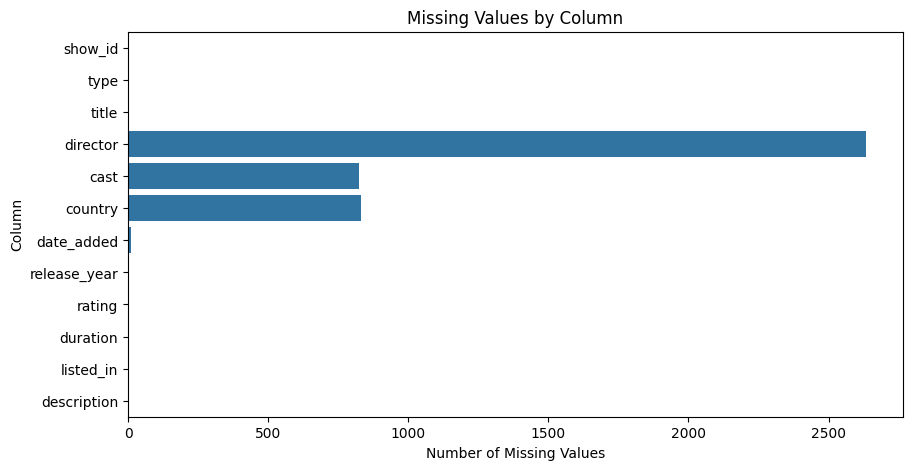

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=df.isnull().sum().values,
    y=df.isnull().sum().index
)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.show()

In [ ]:
dup=df.duplicated().sum()
dup

np.int64(0)

In [ ]:
df.nunique()


,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1767
release_year,74
rating,17
duration,220


In [ ]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


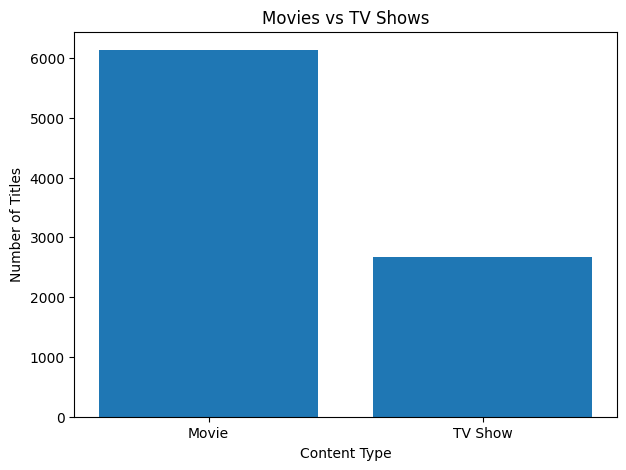

In [ ]:
type_count = df["type"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(type_count.index, type_count.values)

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [ ]:
df["release_year"].min()

1925

In [ ]:
df["release_year"].max()

2021

In [ ]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="mixed"
)

df["added_year"] = df["date_added"].dt.year
content_type_year = (
    df.groupby(["added_year", "type"])
      .size().reset_index(name="count")

)
content_type_year

,added_year,type,count
0,2008.0,Movie,1
1,2008.0,TV Show,1
2,2009.0,Movie,2
3,2010.0,Movie,1
4,2011.0,Movie,13
5,2012.0,Movie,3
6,2013.0,Movie,6
7,2013.0,TV Show,5
8,2014.0,Movie,19
9,2014.0,TV Show,5


In [ ]:
df["date_added"].dtype

dtype('<M8[ns]')

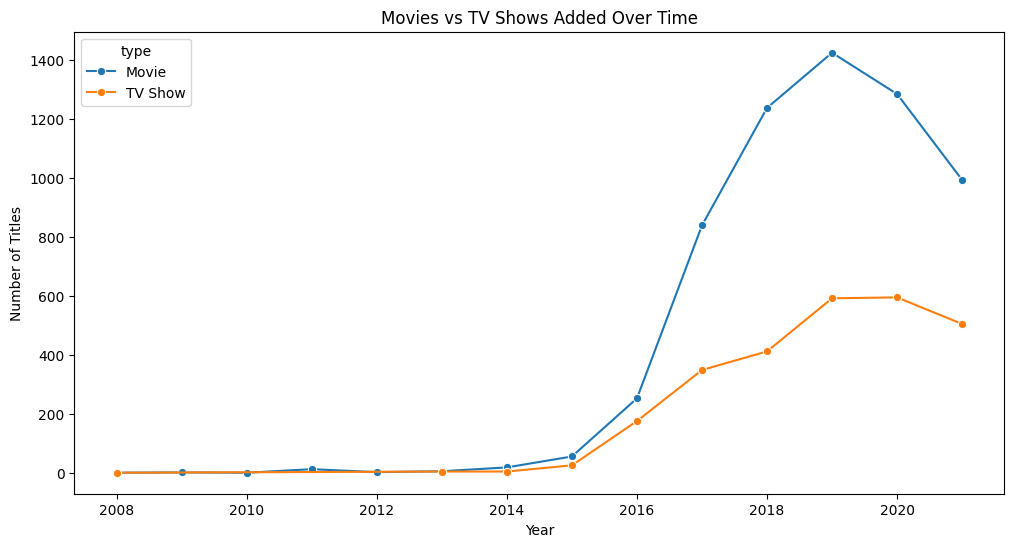

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=content_type_year,
    x="added_year",
    y="count",
    hue="type",
    marker="o"
)

plt.title("Movies vs TV Shows Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

In [ ]:
country_df = df.dropna(subset=["country"]).copy()

country_df["country"] = country_df["country"].str.split(", ")

country_df = country_df.explode("country")
country_count = country_df["country"].value_counts()

country_count.head(10).sort_values(ascending=False)

,count
country,
United States,3689
India,1046
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


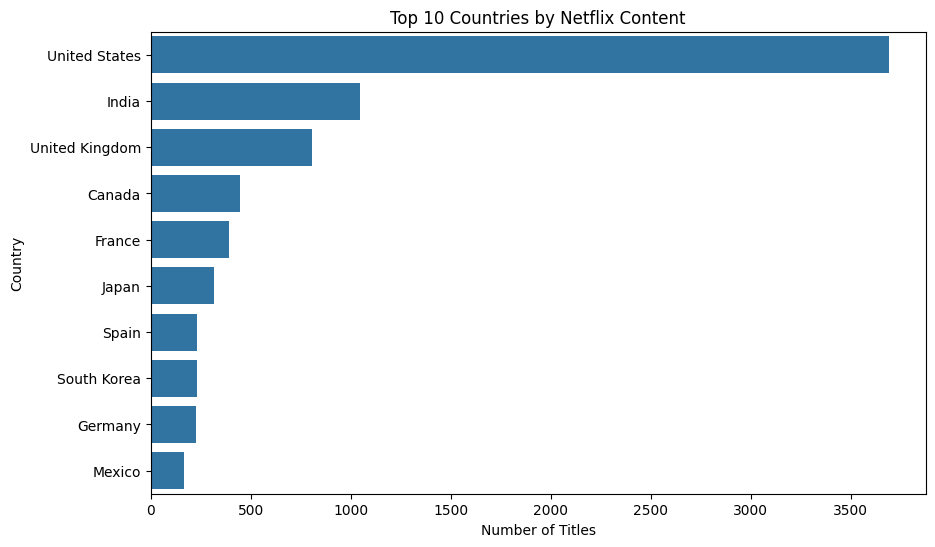

In [ ]:
top_countries = country_count.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

In [ ]:
genre_df = df.dropna(subset=["listed_in"]).copy()

genre_df["listed_in"] = genre_df["listed_in"].str.split(", ")

genre_df = genre_df.explode("listed_in")
genre_count = genre_df["listed_in"].value_counts()

genre_count.head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


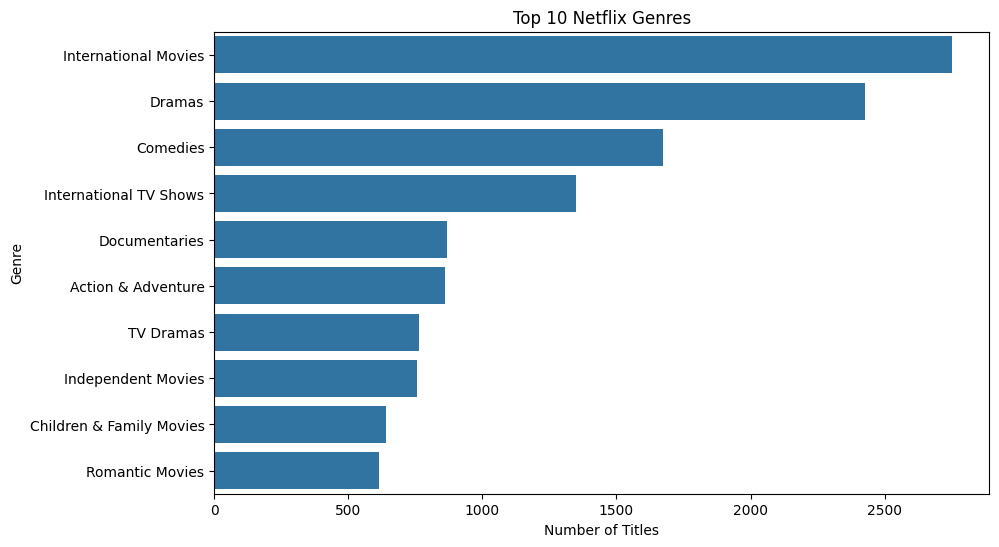

In [ ]:
top_genres = genre_count.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

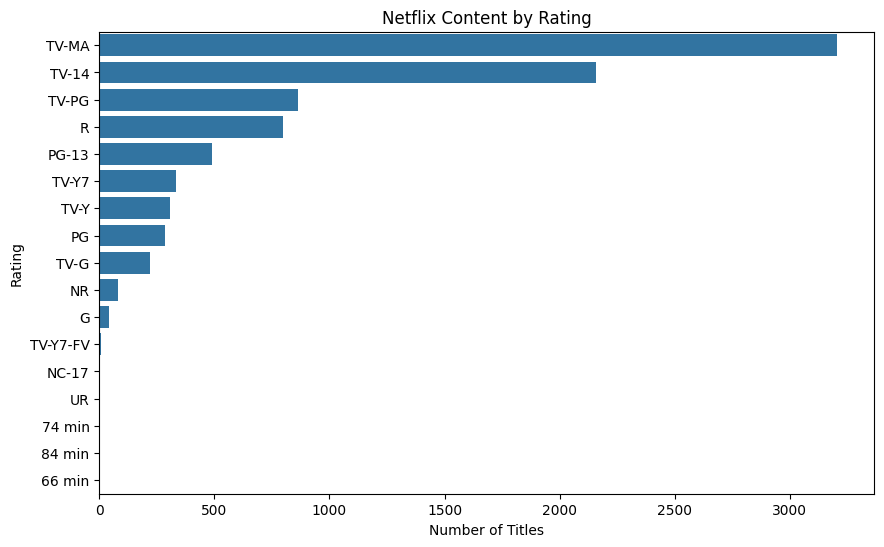

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().index
)

plt.title("Netflix Content by Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

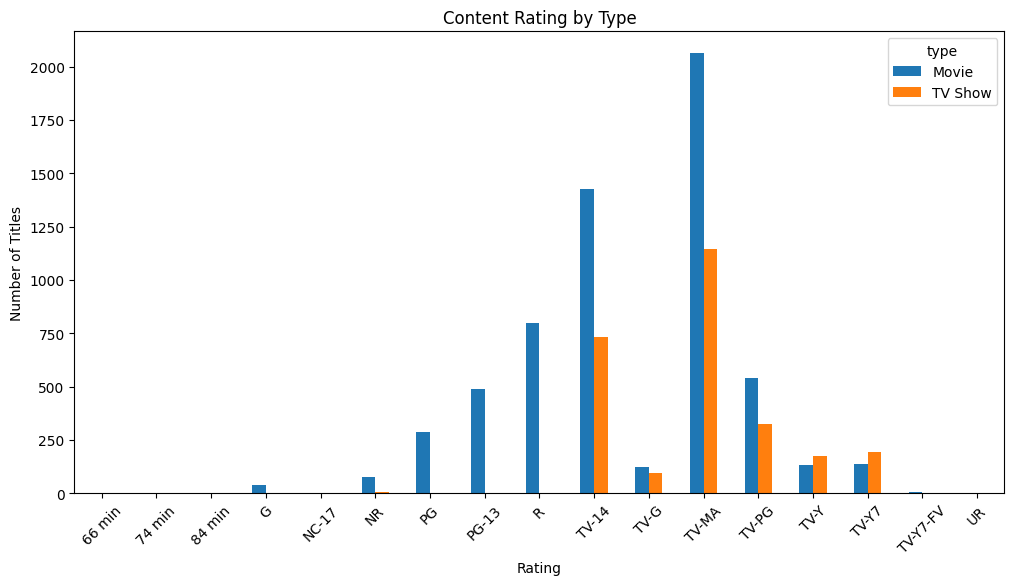

In [ ]:
rating_type = pd.crosstab(
    df["rating"],
    df["type"]
)

rating_type
rating_type.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Content Rating by Type")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [ ]:
director_count = df["director"].value_counts()

director_count.head(10)

,count
director,
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12
Jay Chapman,12


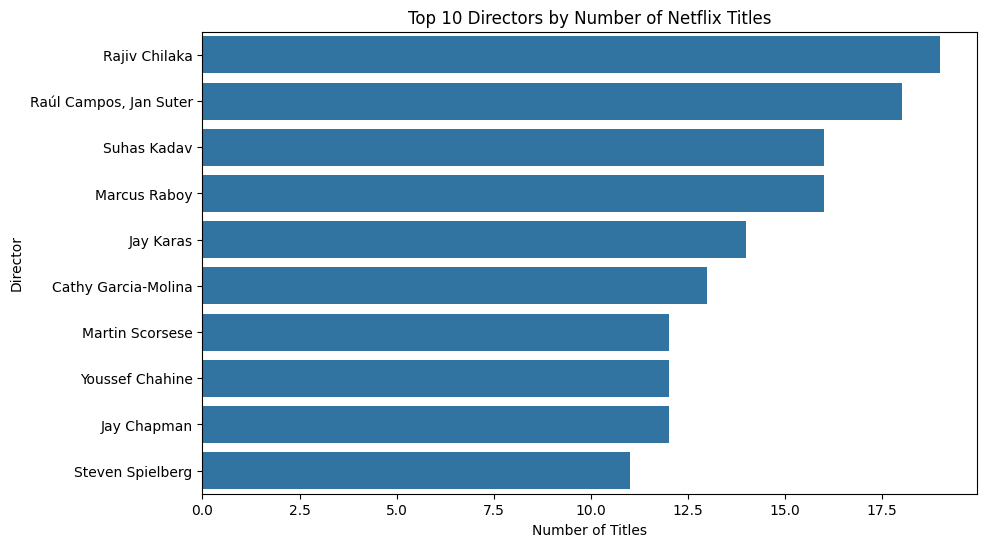

In [ ]:
top_directors = director_count.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top 10 Directors by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

In [ ]:
cast_df = df.dropna(subset=["cast"]).copy()

cast_df["cast"] = cast_df["cast"].str.split(", ")

cast_df = cast_df.explode("cast")
cast_count = cast_df["cast"].value_counts()

cast_count.head(10)

,count
cast,
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Takahiro Sakurai,32
Naseeruddin Shah,32
Rupa Bhimani,31
Om Puri,30
Akshay Kumar,30
Yuki Kaji,29


In [ ]:
country_type = pd.crosstab(
    country_df["country"],
    country_df["type"]
)
top_country_names = country_count.head(10).index

country_type_top = country_type.loc[
    country_type.index.intersection(top_country_names)
]

country_type_top

type,Movie,TV Show
country,,
Canada,319,126
France,303,90
Germany,182,44
India,962,84
Japan,119,199
Mexico,111,58
South Korea,61,170
Spain,171,61
United Kingdom,532,272


In [ ]:
genre_type = pd.crosstab(
    genre_df["listed_in"],
    genre_df["type"]
)
top_genre_names = genre_count.head(10).reset_index()

top_genre_names

,listed_in,count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


In [ ]:
#newest content
df.sort_values(
    "release_year",
    ascending=False
).head(10)[
    ["title", "type", "release_year"]
]

,title,type,release_year
1,Blood & Water,TV Show,2021
2,Ganglands,TV Show,2021
3,Jailbirds New Orleans,TV Show,2021
31,Chicago Party Aunt,TV Show,2021
30,Ankahi Kahaniya,Movie,2021
25,Love on the Spectrum,TV Show,2021
23,Go! Go! Cory Carson: Chrissy Takes the Wheel,Movie,2021
20,Monsters Inside: The 24 Faces of Billy Milligan,TV Show,2021
19,Jaguar,TV Show,2021
18,Intrusion,Movie,2021


In [ ]:
movie_df = df[df["type"] == "Movie"].copy()
movie_df["duration_min"] = (
    movie_df["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)
duration = movie_df["duration_min"].dropna().to_numpy()
print("Mean:", np.mean(duration))
print("Median:", np.median(duration))
print("Standard Deviation:", np.std(duration))
print("Minimum:", np.min(duration))
print("Maximum:", np.max(duration))



Mean: 99.57718668407311
Median: 98.0
Standard Deviation: 28.288285047638155
Minimum: 3.0
Maximum: 312.0


In [ ]:
data_quality = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values": df.nunique()
})

data_quality

,Data Type,Missing Values,Missing %,Unique Values
show_id,object,0,0.00,8807
type,object,0,0.00,2
title,object,0,0.00,8807
director,object,2634,29.91,4528
cast,object,825,9.37,7692
country,object,831,9.44,748
date_added,datetime64[ns],10,0.11,1714
release_year,int64,0,0.00,74
rating,object,4,0.05,17
duration,object,3,0.03,220


In [ ]:
summary = {
    "Total Titles": len(df),
    "Movies": (df["type"] == "Movie").sum(),
    "TV Shows": (df["type"] == "TV Show").sum(),
    "Unique Directors": df["director"].nunique(),
    "Unique Countries": country_count.size,
    "Unique Genres": genre_count.size,
    "Oldest Release Year": df["release_year"].min(),
    "Newest Release Year": df["release_year"].max()
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Total Titles,8807
1,Movies,6131
2,TV Shows,2676
3,Unique Directors,4528
4,Unique Countries,127
5,Unique Genres,42
6,Oldest Release Year,1925
7,Newest Release Year,2021
